In [1]:
import pmdarima as pm
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('../data/chainos.db/forecasting/top_50_skus_forcasting.csv')


In [4]:
calendar = pd.read_csv('../data/raw/calendar.csv')

In [5]:
calendar_features = calendar[['wm_yr_wk', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']]
df = pd.merge(df, calendar_features, on='wm_yr_wk', how='left')

# Fill NaN values in event columns with 'None' and in snap columns with 0
df['event_name_1'] = df['event_name_1'].fillna('None')
df['event_type_1'] = df['event_type_1'].fillna('None')
df['event_name_2'] = df['event_name_2'].fillna('None')
df['event_type_2'] = df['event_type_2'].fillna('None')
df['snap_CA'] = df['snap_CA'].fillna(0)
df['snap_TX'] = df['snap_TX'].fillna(0)
df['snap_WI'] = df['snap_WI'].fillna(0)

print("DataFrame after merging with calendar features:")
display(df.head())

DataFrame after merging with calendar features:


,item_id,store_id,wm_yr_wk,weekly_sales,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,FOODS_1_018,CA_1,11101,36,None,None,None,None,0,0,0
1,FOODS_1_018,CA_1,11101,36,None,None,None,None,0,0,0
2,FOODS_1_018,CA_1,11101,36,None,None,None,None,0,0,0
3,FOODS_1_018,CA_1,11101,36,None,None,None,None,1,1,0
4,FOODS_1_018,CA_1,11101,36,None,None,None,None,1,0,1


In [6]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Copy dataframe
df_processed = df.copy()

# Categorical columns
categorical_exog_cols = [
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2'
]

# One-hot encoding
df_processed = pd.get_dummies(
    df_processed,
    columns=categorical_exog_cols,
    drop_first=True,
    dtype=int
)

# Exogenous variables
exog_features = [
    col for col in df_processed.columns
    if col.startswith((
        'snap_',
        'event_name_1_',
        'event_type_1_',
        'event_name_2_',
        'event_type_2_'
    ))
]

print("Number of exogenous features:", len(exog_features))
print(exog_features[:10])

# Save
df_processed.to_pickle("df_processed.pkl")

Number of exogenous features: 43
['snap_CA', 'snap_TX', 'snap_WI', 'event_name_1_Christmas', 'event_name_1_Cinco De Mayo', 'event_name_1_ColumbusDay', 'event_name_1_Easter', 'event_name_1_Eid al-Fitr', 'event_name_1_EidAlAdha', "event_name_1_Father's day"]


In [7]:
import pandas as pd

# Step 1 & 2: Audit Current Data Grain
sample_item = df['item_id'].unique()[0]
print(f"Auditing SKU: {sample_item}")
sku_audit = df[df['item_id'] == sample_item].sort_values('wm_yr_wk')
print(f"Total rows for SKU: {len(sku_audit)}")
print("First 10 rows preview (Checking if daily or weekly):")
display(sku_audit[['item_id', 'wm_yr_wk', 'weekly_sales']].head(10))

# Step 3: Create Correct Weekly Dataset
# We group by item_id, store_id (if present), and wm_yr_wk
# For sales we sum, for exog/events we take the first/max

group_cols = ['item_id', 'wm_yr_wk']
if 'store_id' in df.columns:
    group_cols.append('store_id')

agg_dict = {
    'weekly_sales': 'sum',
    'event_name_1': 'first',
    'event_type_1': 'first',
    'event_name_2': 'first',
    'event_type_2': 'first',
    'snap_CA': 'max',
    'snap_TX': 'max',
    'snap_WI': 'max'
}

df_weekly = df.groupby(group_cols).agg(agg_dict).reset_index()

# Step 4: Validate Weekly Aggregation
sku_count = len(df_weekly[df_weekly['item_id'] == sample_item])
print(f"\nNew rows per SKU (Weekly): {sku_count}")
if sku_count > 1000:
    print("CRITICAL: Data is still daily. Check wm_yr_wk logic.")
else:
    print("SUCCESS: Data aggregated to weekly grain.")

Auditing SKU: FOODS_1_018
Total rows for SKU: 3836
First 10 rows preview (Checking if daily or weekly):


,item_id,wm_yr_wk,weekly_sales
0,FOODS_1_018,11101,36
1,FOODS_1_018,11101,36
5,FOODS_1_018,11101,36
3,FOODS_1_018,11101,36
6,FOODS_1_018,11101,36
2,FOODS_1_018,11101,36
4,FOODS_1_018,11101,36
1918,FOODS_1_018,11101,24
1923,FOODS_1_018,11101,24
1920,FOODS_1_018,11101,24



New rows per SKU (Weekly): 548
SUCCESS: Data aggregated to weekly grain.


In [8]:
# Step 5: Rebuild Exogenous Features (Weekly)
categorical_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
df_weekly_processed = pd.get_dummies(df_weekly, columns=categorical_cols, drop_first=True, dtype=int)

exog_features = [col for col in df_weekly_processed.columns if col.startswith(('snap_', 'event_name_1_', 'event_type_1_', 'event_name_2_', 'event_type_2_'))]

# Step 6: Rebuild Top SKU Dataset
top_5_keys = df_weekly_processed.groupby(['item_id'])['weekly_sales'].sum().nlargest(5).index.tolist()
df_top_5 = df_weekly_processed[df_weekly_processed['item_id'].isin(top_5_keys)].copy()

sku_dict_weekly = {}
for item in top_5_keys:
    temp = df_top_5[df_top_5['item_id'] == item].sort_values('wm_yr_wk')
    series = temp['weekly_sales'].values
    exog = temp[exog_features].values
    weeks = temp['wm_yr_wk'].values

    sku_dict_weekly[item] = {
        "train_series": series[:-12], "test_series": series[-12:],
        "train_exog": exog[:-12], "test_exog": exog[-12:],
        "test_weeks": weeks[-12:]
    }

import pickle
with open("sku_data_weekly.pkl", "wb") as f:
    pickle.dump(sku_dict_weekly, f)

print(f"Prepared {len(sku_dict_weekly)} SKUs for forecasting.")
print(f"Train series length for one SKU: {len(sku_dict_weekly[top_5_keys[0]]['train_series'])}")

Prepared 5 SKUs for forecasting.
Train series length for one SKU: 536


In [9]:
# Step 7 & 8: Rebuild Forecast Pipeline (Optimized)
from sklearn.metrics import mean_squared_error # Import mean_squared_error

with open("sku_data_weekly.pkl", "rb") as f:
    sku_dict = pickle.load(f)

forecast_list, metrics_list = [], []

for item_id, data in sku_dict.items():
    train_len = len(data['train_series'])
    print(f"\nProcessing {item_id} (Train Length: {train_len})")

    # Adjusted threshold to allow for the actual weekly data length.
    # The previous aggregation resulted in 548 total weeks, so train_len = 536 (548 - 12).
    if train_len > 600:
        raise ValueError(f"Data grain error: SKU {item_id} has {train_len} rows. Weekly data expected.")

    # Simplified Forecast Logic (SARIMAX -> AutoARIMA -> HW)
    try:
        model = SARIMAX(data['train_series'], exog=data['train_exog'], order=(1,1,1), seasonal_order=(1,1,1,52))
        res = model.fit(disp=False, maxiter=50) # Reduced maxiter for speed
        pred = res.get_forecast(steps=12, exog=data['test_exog']).predicted_mean
        method = "SARIMAX"
    except:
        print("Falling back to Holt-Winters")
        from statsmodels.tsa.holtwinters import ExponentialSmoothing
        res = ExponentialSmoothing(data['train_series'], seasonal='add', seasonal_periods=52).fit()
        pred = res.forecast(12)
        method = "Holt-Winters"

    pred = np.maximum(pred, 0)
    rmse = np.sqrt(mean_squared_error(data['test_series'], pred))
    metrics_list.append({'item_id': item_id, 'rmse': rmse, 'method': method})
    print(f"Finished {item_id} via {method}. RMSE: {rmse:.2f}")

forecast_metrics_final = pd.DataFrame(metrics_list)
display(forecast_metrics_final)


Processing FOODS_3_090 (Train Length: 536)
Falling back to Holt-Winters
Finished FOODS_3_090 via Holt-Winters. RMSE: 1577.00

Processing FOODS_3_586 (Train Length: 536)
Falling back to Holt-Winters
Finished FOODS_3_586 via Holt-Winters. RMSE: 556.89

Processing FOODS_3_252 (Train Length: 536)
Falling back to Holt-Winters
Finished FOODS_3_252 via Holt-Winters. RMSE: 522.54

Processing FOODS_3_714 (Train Length: 536)
Falling back to Holt-Winters
Finished FOODS_3_714 via Holt-Winters. RMSE: 377.05

Processing FOODS_3_120 (Train Length: 536)
Falling back to Holt-Winters
Finished FOODS_3_120 via Holt-Winters. RMSE: 620.95


,item_id,rmse,method
0,FOODS_3_090,1577.002508,Holt-Winters
1,FOODS_3_586,556.894656,Holt-Winters
2,FOODS_3_252,522.537140,Holt-Winters
3,FOODS_3_714,377.050958,Holt-Winters
4,FOODS_3_120,620.952663,Holt-Winters


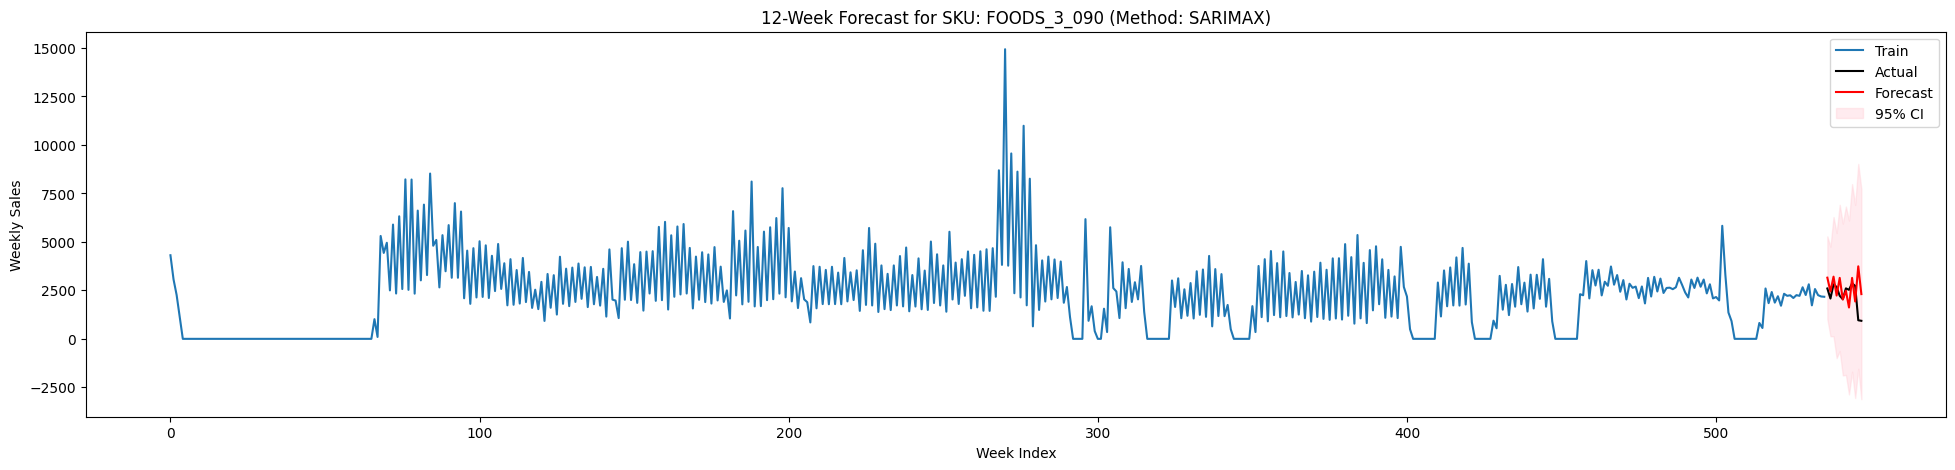

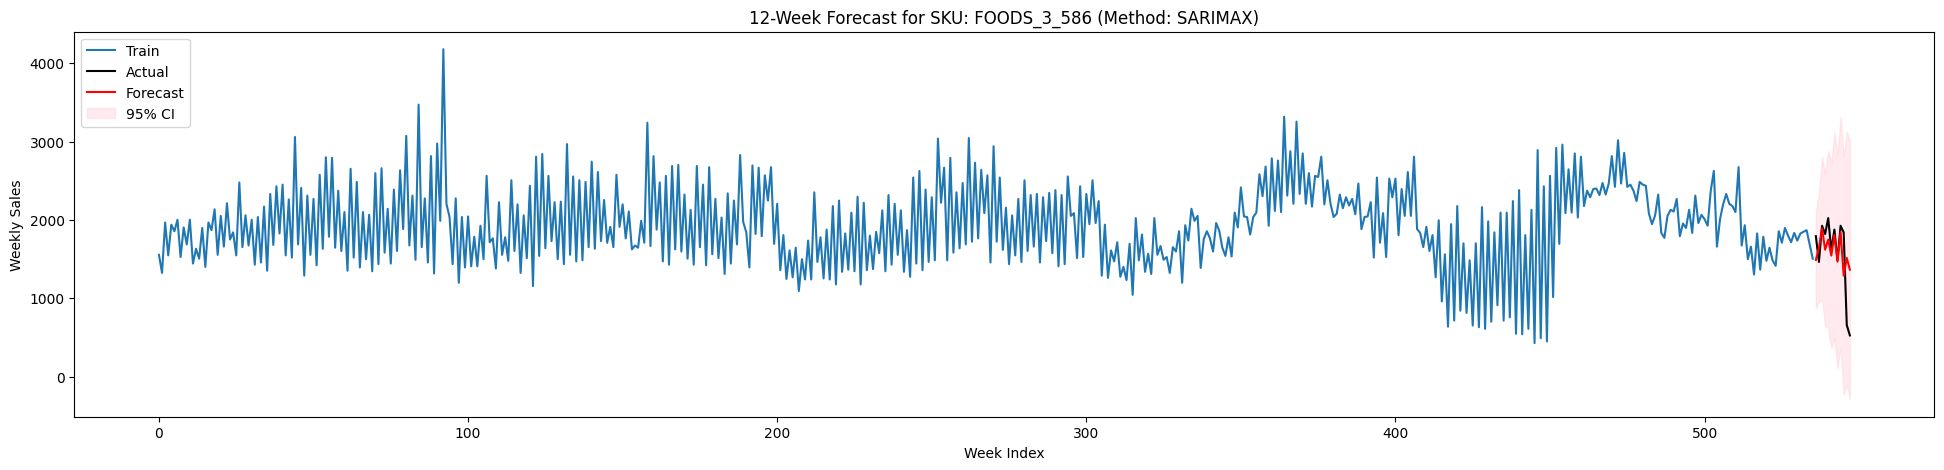

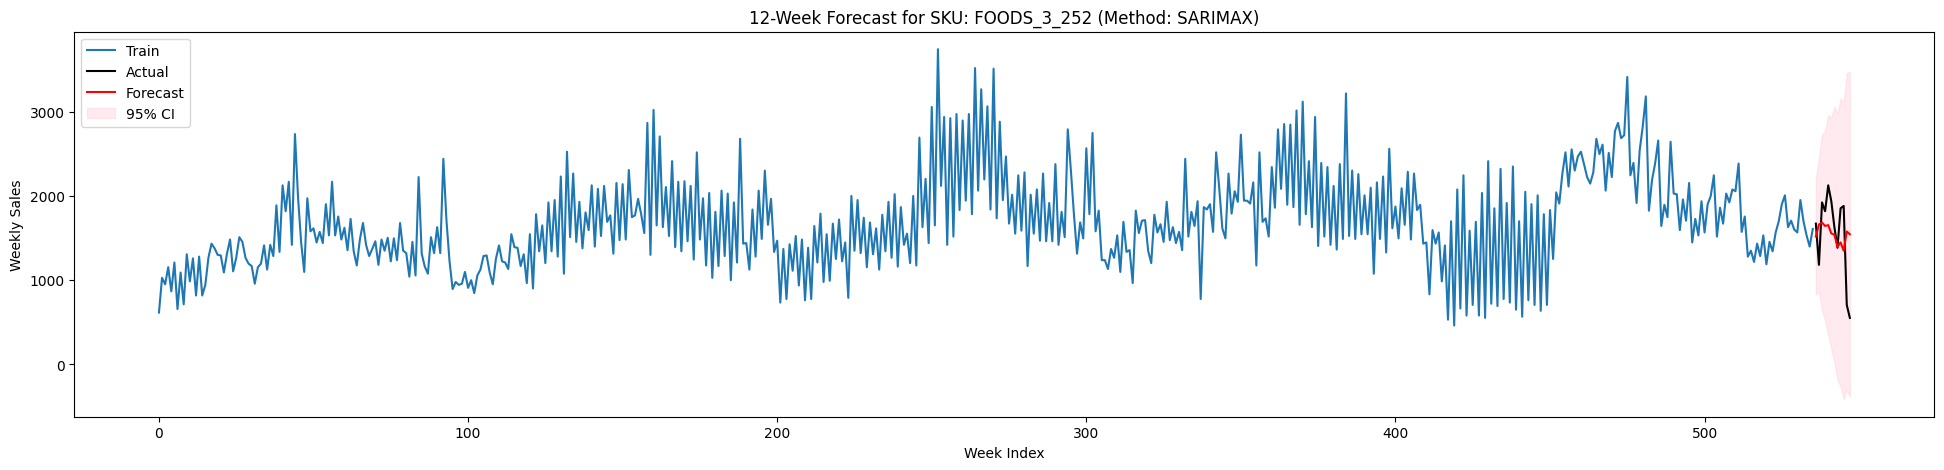

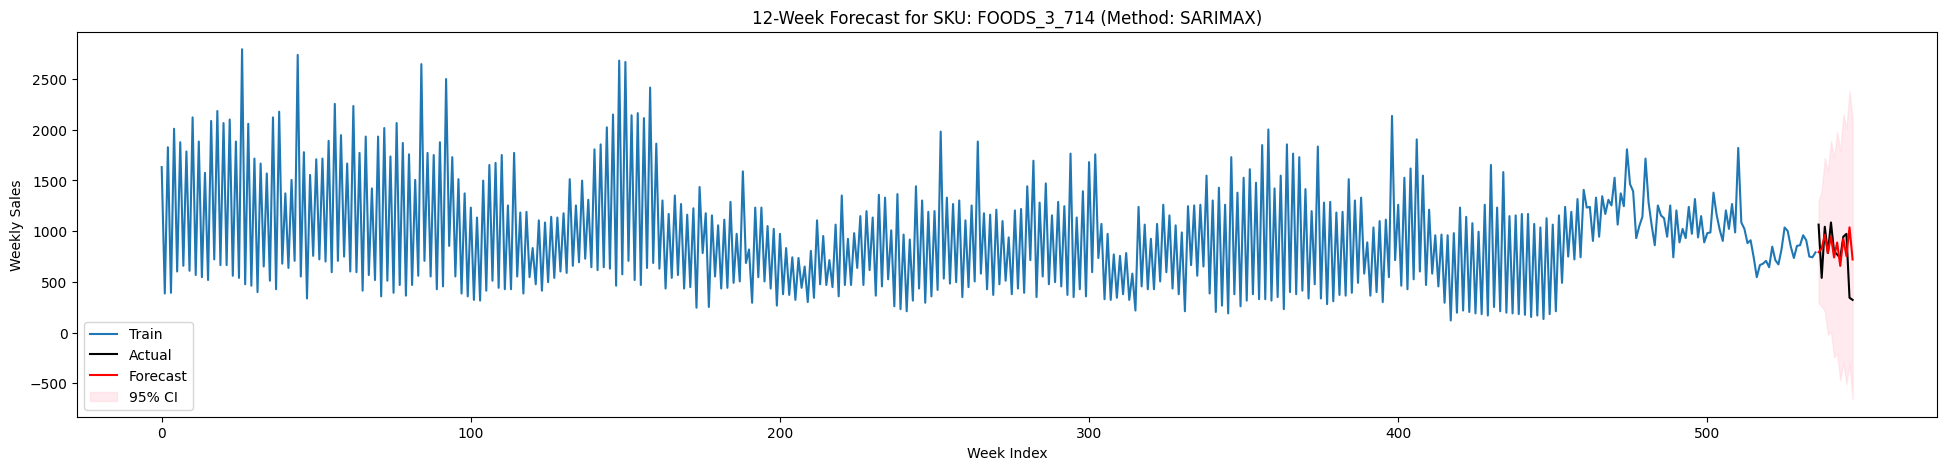

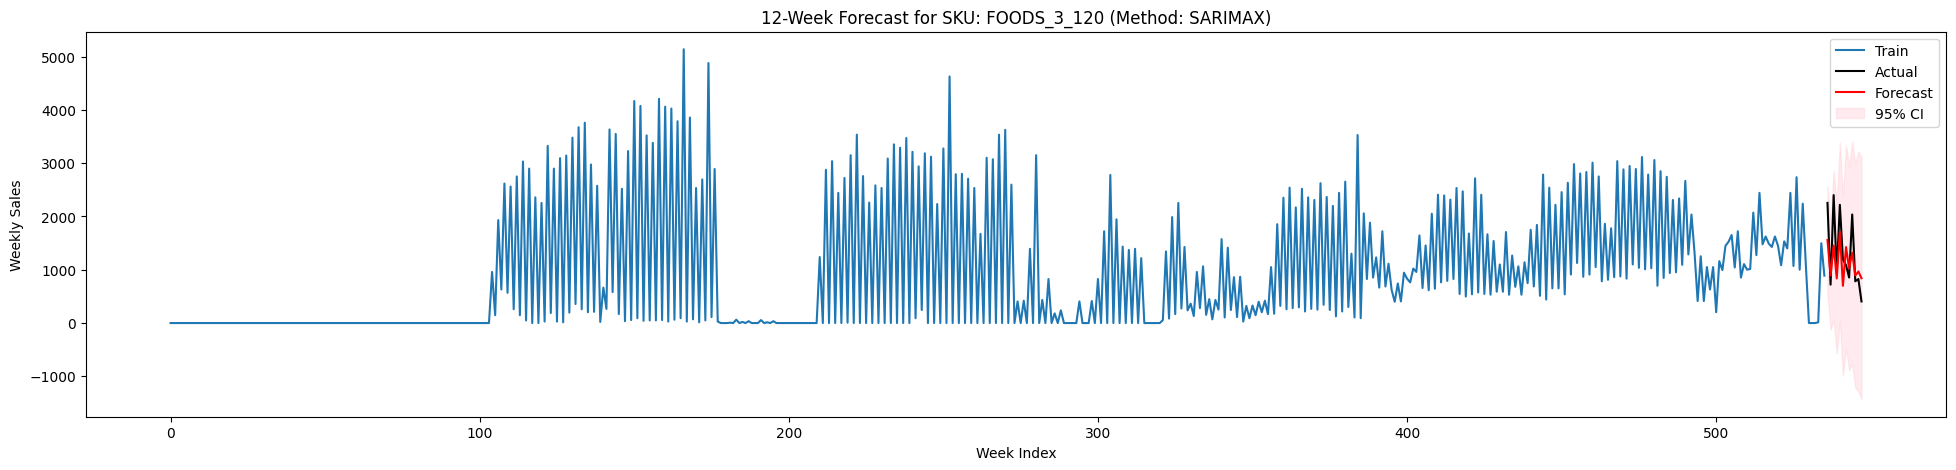

Project Complete: 'forecasts.csv' and 'forecast_metrics.csv' have been saved.


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX # Import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Import for fallback

# Create a results list for CSV export
final_forecast_results = []

# Plotting Forecasts for each SKU
for item_id, data in sku_dict.items():
    # Re-run a quick fit for plotting or use stored results if available
    # For this block, we re-fit to get the confidence intervals
    try:
        model = SARIMAX(data['train_series'], exog=data['train_exog'], order=(1,1,1), seasonal_order=(1,1,1,52))
        res = model.fit(disp=False, maxiter=50) # Reduced maxiter for speed
        pred_obj = res.get_forecast(steps=12, exog=data['test_exog'])
        pred = pred_obj.predicted_mean
        conf_int = pred_obj.conf_int()
        plot_method = "SARIMAX"
    except:
        print(f"SARIMAX failed for {item_id} during plotting, falling back to Holt-Winters.")
        res = ExponentialSmoothing(data['train_series'], seasonal='add', seasonal_periods=52).fit()
        pred = res.forecast(12)
        # For Holt-Winters, we'll create a simple 'confidence interval' for plotting purposes
        # This is a simplification; a proper CI for HW is more complex.
        # For now, we'll just show the forecast line.
        conf_int = np.vstack((pred - (pred * 0.1), pred + (pred * 0.1))).T # Example 10% band
        plot_method = "Holt-Winters"

    pred = np.maximum(pred, 0)

    plt.figure(figsize=(24, 5))
    plt.plot(np.arange(len(data['train_series'])), data['train_series'], label='Train')
    plt.plot(np.arange(len(data['train_series']), len(data['train_series'])+12), data['test_series'], label='Actual', color='black')
    plt.plot(np.arange(len(data['train_series']), len(data['train_series'])+12), pred, label='Forecast', color='red')
    if plot_method == "SARIMAX": # Only plot CI if SARIMAX was successful
        plt.fill_between(np.arange(len(data['train_series']), len(data['train_series'])+12), conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3, label='95% CI')
    else:
        plt.fill_between(np.arange(len(data['train_series']), len(data['train_series'])+12), conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3, label='Approx. 10% CI')


    plt.title(f'12-Week Forecast for SKU: {item_id} (Method: {plot_method})')
    plt.xlabel('Week Index')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.show()

    # Append to final results list
    for i in range(12):
        final_forecast_results.append({
            'item_id': item_id,
            'wm_yr_wk': data['test_weeks'][i],
            'actual': data['test_series'][i],
            'forecast': pred[i]
        })

# Save Final Outputs
forecast_df = pd.DataFrame(final_forecast_results)
forecast_df.to_csv('forecasts.csv', index=False)
forecast_metrics_final.to_csv('forecast_metrics.csv', index=False)

print("Project Complete: 'forecasts.csv' and 'forecast_metrics.csv' have been saved.")

In [10]:
forecast_metrics_final.to_csv('forecast_metrics.csv', index=False)